In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix

In [3]:
X, y = load_breast_cancer(as_frame=True, return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
517,19.89,20.26,130.50,1214.0,0.10370,0.13100,0.1411,0.09431,0.1802,0.06188,...,23.73,25.23,160.5,1646.0,0.14170,0.3309,0.4185,0.16130,0.2549,0.09136
287,12.89,13.12,81.89,515.9,0.06955,0.03729,0.0226,0.01171,0.1337,0.05581,...,13.62,15.54,87.4,577.0,0.09616,0.1147,0.1186,0.05366,0.2309,0.06915
25,17.14,16.40,116.00,912.7,0.11860,0.22760,0.2229,0.14010,0.3040,0.07413,...,22.25,21.40,152.4,1461.0,0.15450,0.3949,0.3853,0.25500,0.4066,0.10590
253,17.30,17.08,113.00,928.2,0.10080,0.10410,0.1266,0.08353,0.1813,0.05613,...,19.85,25.09,130.9,1222.0,0.14160,0.2405,0.3378,0.18570,0.3138,0.08113
369,22.01,21.90,147.20,1482.0,0.10630,0.19540,0.2448,0.15010,0.1824,0.06140,...,27.66,25.80,195.0,2227.0,0.12940,0.3885,0.4756,0.24320,0.2741,0.08574


In [4]:
lr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

dt = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(n_estimators=300, random_state=42)

models = {
    "LogReg": lr,
    "DecisionTree": dt,
    "RandomForest": rf
}

probas = {}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    p = model.predict_proba(X_test)[:, 1]
    probas[name] = p

    acc = accuracy_score(y_test, pred)
    auc = roc_auc_score(y_test, p)

    results.append((name, acc, auc))

pd.DataFrame(results, columns=["Model", "Accuracy", "ROC_AUC"]).sort_values("ROC_AUC", ascending=False)

,Model,Accuracy,ROC_AUC
0,LogReg,0.986014,0.997694
2,RandomForest,0.958042,0.994864
1,DecisionTree,0.923077,0.923375


In [5]:
voting = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("dt", dt),
        ("rf", rf)
    ],
    voting="soft"
)

voting.fit(X_train, y_train)

pred_vote = voting.predict(X_test)
proba_vote = voting.predict_proba(X_test)[:, 1]

probas["Voting (soft)"] = proba_vote

acc_vote = accuracy_score(y_test, pred_vote)
auc_vote = roc_auc_score(y_test, proba_vote)

print("VotingClassifier (soft)")
print("Accuracy:", round(acc_vote, 3))
print("ROC AUC:", round(auc_vote, 3))

VotingClassifier (soft)
Accuracy: 0.944
ROC AUC: 0.994


In [6]:
stack = StackingClassifier(
     estimators=[
        ("lr", lr),
        ("dt", dt),
        ("rf", rf)
    ],
    final_estimator=LogisticRegression(max_iter=500),
    stack_method="predict_proba"
)

stack.fit(X_train, y_train)

pred_stack = stack.predict(X_test)
proba_stack = stack.predict_proba(X_test)[:, 1]

probas["Stacking"] = proba_stack

acc_stack = accuracy_score(y_test, pred_stack)
auc_stack = roc_auc_score(y_test, proba_stack)

print("StackingClassifier")
print("Accuracy:", round(acc_stack, 3))
print("ROC AUC:", round(auc_stack, 3))

StackingClassifier
Accuracy: 0.986
ROC AUC: 0.998


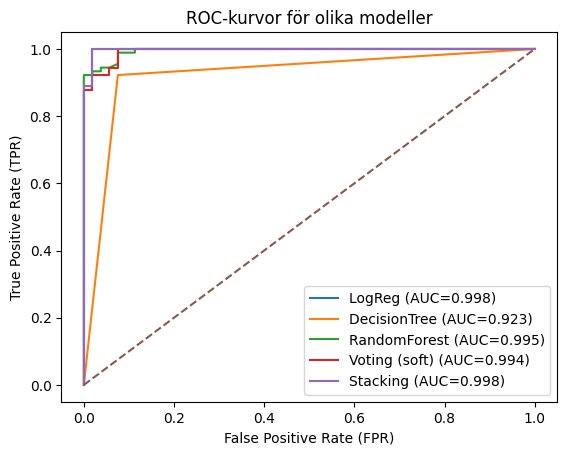

In [7]:
plt.figure()

for name, p in probas.items():
    fpr, tpr, thresholds = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC-kurvor för olika modeller")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.show()

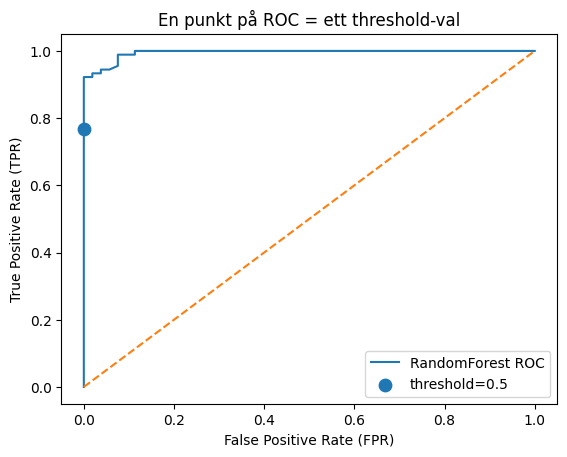

In [10]:
p = probas["RandomForest"]
threshold = 0.9

pred_thr = (p >= threshold).astype(int)


# [[TN, FP],
#  [FN, TP]]
cm = confusion_matrix(y_test, pred_thr)
tn, fp, fn, tp = cm.ravel()

fpr_point = fp / (fp + tn)
tpr_point = tp / (tp + fn)


fpr, tpr, thresholds = roc_curve(y_test, p)

plt.figure()
plt.plot(fpr, tpr, label="RandomForest ROC")
plt.plot([0,1], [0,1], linestyle="--")
plt.scatter([fpr_point], [tpr_point], s=80, label="threshold=0.5")
plt.title("En punkt på ROC = ett threshold-val")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.show()

In [9]:
summary = pd.DataFrame(
    [
        ("LogReg", results[0][1], results[0][2]),
        ("DecisionTree", results[1][1], results[1][2]),
        ("RandomForest", results[2][1], results[2][2]),
        ("Voting (soft)", acc_vote, auc_vote),
        ("Stacking", acc_stack, auc_stack),
    ],
    columns=["Model", "Accuracy", "ROC_AUC"]
).sort_values("ROC_AUC", ascending=False)

summary

,Model,Accuracy,ROC_AUC
4,Stacking,0.986014,0.997904
0,LogReg,0.986014,0.997694
2,RandomForest,0.958042,0.994864
3,Voting (soft),0.944056,0.993711
1,DecisionTree,0.923077,0.923375
